# Feature–Target Analysis

## Introduction
* This notebook analyzes the relationship between input features and the target
variable (`Churn`) to identify patterns associated with customer churn in the
IBM Telco Customer Churn dataset.


In [37]:
import sys
from pathlib import Path

# Add project root to PYTHONPATH
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.utils.config import PROCESSED_DATA_PATH

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [39]:
df = pd.read_csv(PROCESSED_DATA_PATH / "telco_customer_churn_validated.csv")

## Target Distribution

In [40]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

* The dataset exhibits a moderate class imbalance, with fewer churned customers
than non-churned customers.

## Numerical Features vs Target


In [41]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

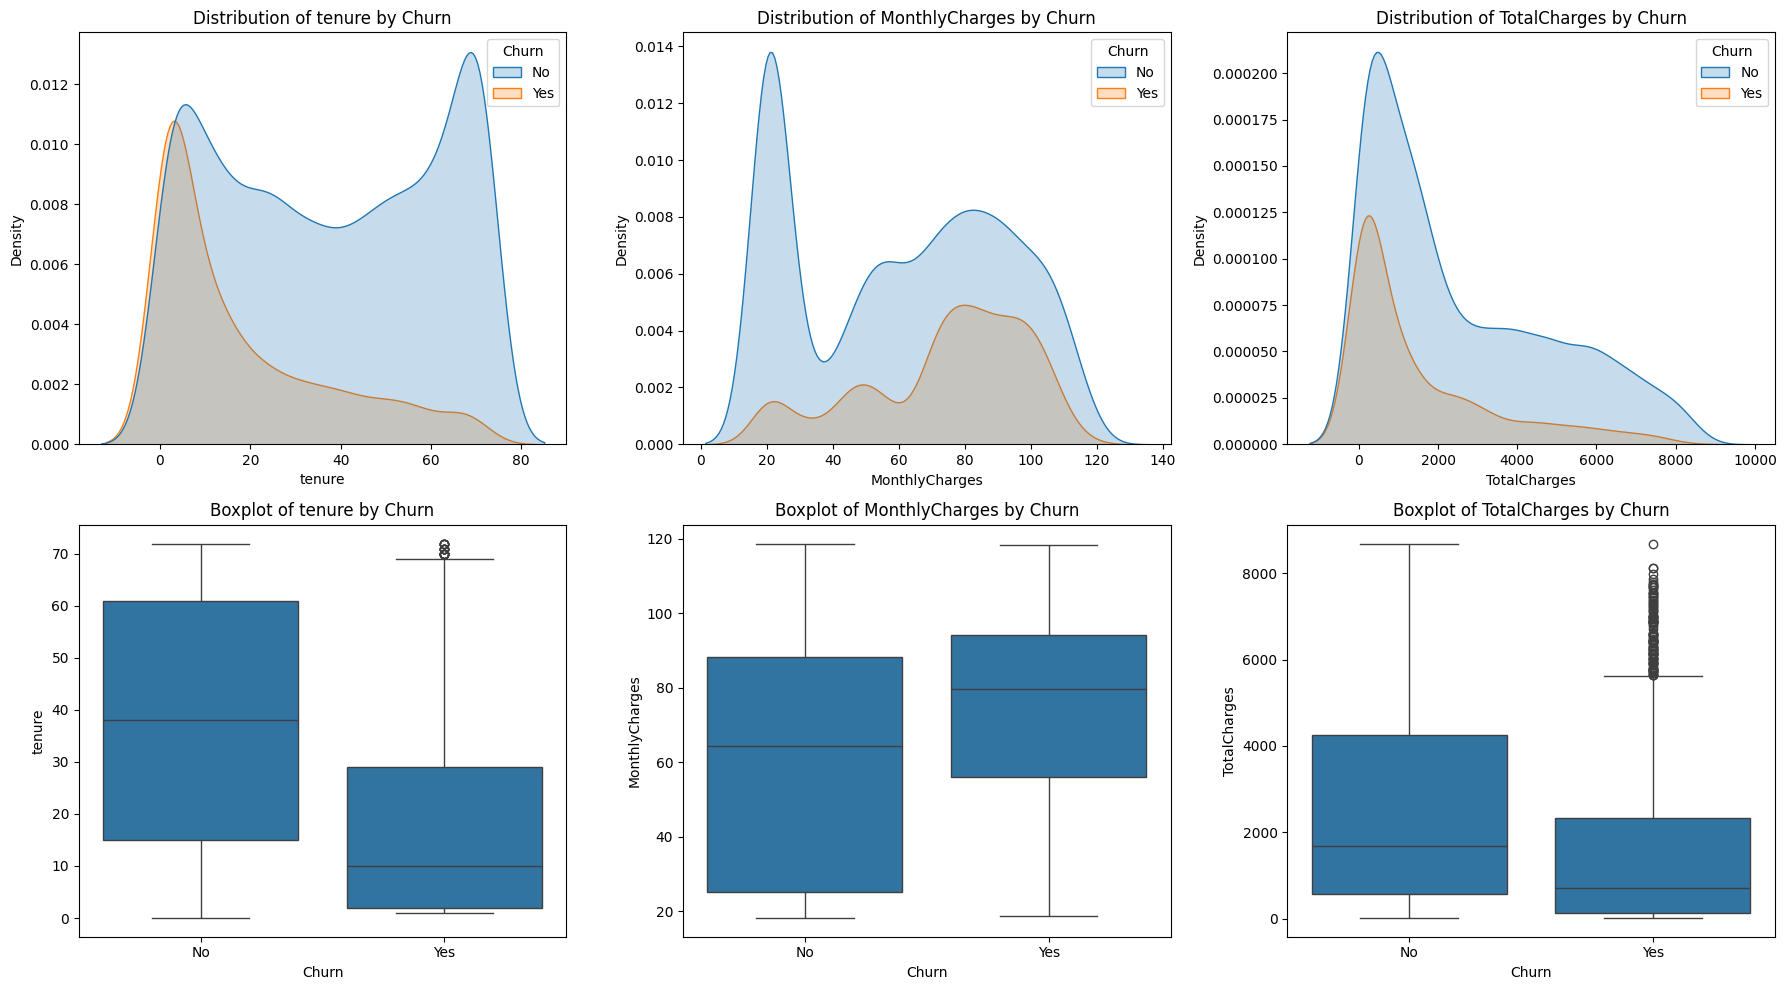

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, col in enumerate(numeric_cols):
    sns.kdeplot(data=df, x=col, hue="Churn", ax=axes[0, i], fill=True)
    sns.boxplot(data=df, x="Churn", y=col, ax=axes[1, i])
    axes[0, i].set_title(f"Distribution of {col} by Churn")
    axes[1, i].set_title(f"Boxplot of {col} by Churn")
plt.tight_layout()
plt.show()

### Numerical Features vs Churn – Key Findings

- **Tenure is strongly associated with churn behavior.**  
  Customers who churn tend to have significantly shorter tenure, with a clear
  concentration in the early months of the customer lifecycle, whereas
  non-churned customers are distributed across longer tenures.

- **Higher monthly charges are associated with increased churn risk.**  
  The distribution of MonthlyCharges for churned customers is shifted toward
  higher values compared to non-churned customers, indicating potential price
  sensitivity among churned users.

- **Differences in TotalCharges are primarily driven by tenure length rather
  than monthly pricing alone.**  
  Non-churned customers accumulate higher TotalCharges over time due to longer
  tenure, while churned customers often exhibit lower TotalCharges despite
  higher MonthlyCharges because they leave earlier.


## Categorical Features vs Target

In [43]:
categorial_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorial_cols.append("SeniorCitizen")
categorial_cols.remove("customerID")
categorial_cols.remove("Churn")
categorial_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

In [44]:
pd.crosstab(df.SeniorCitizen, df.Churn, normalize="index")

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


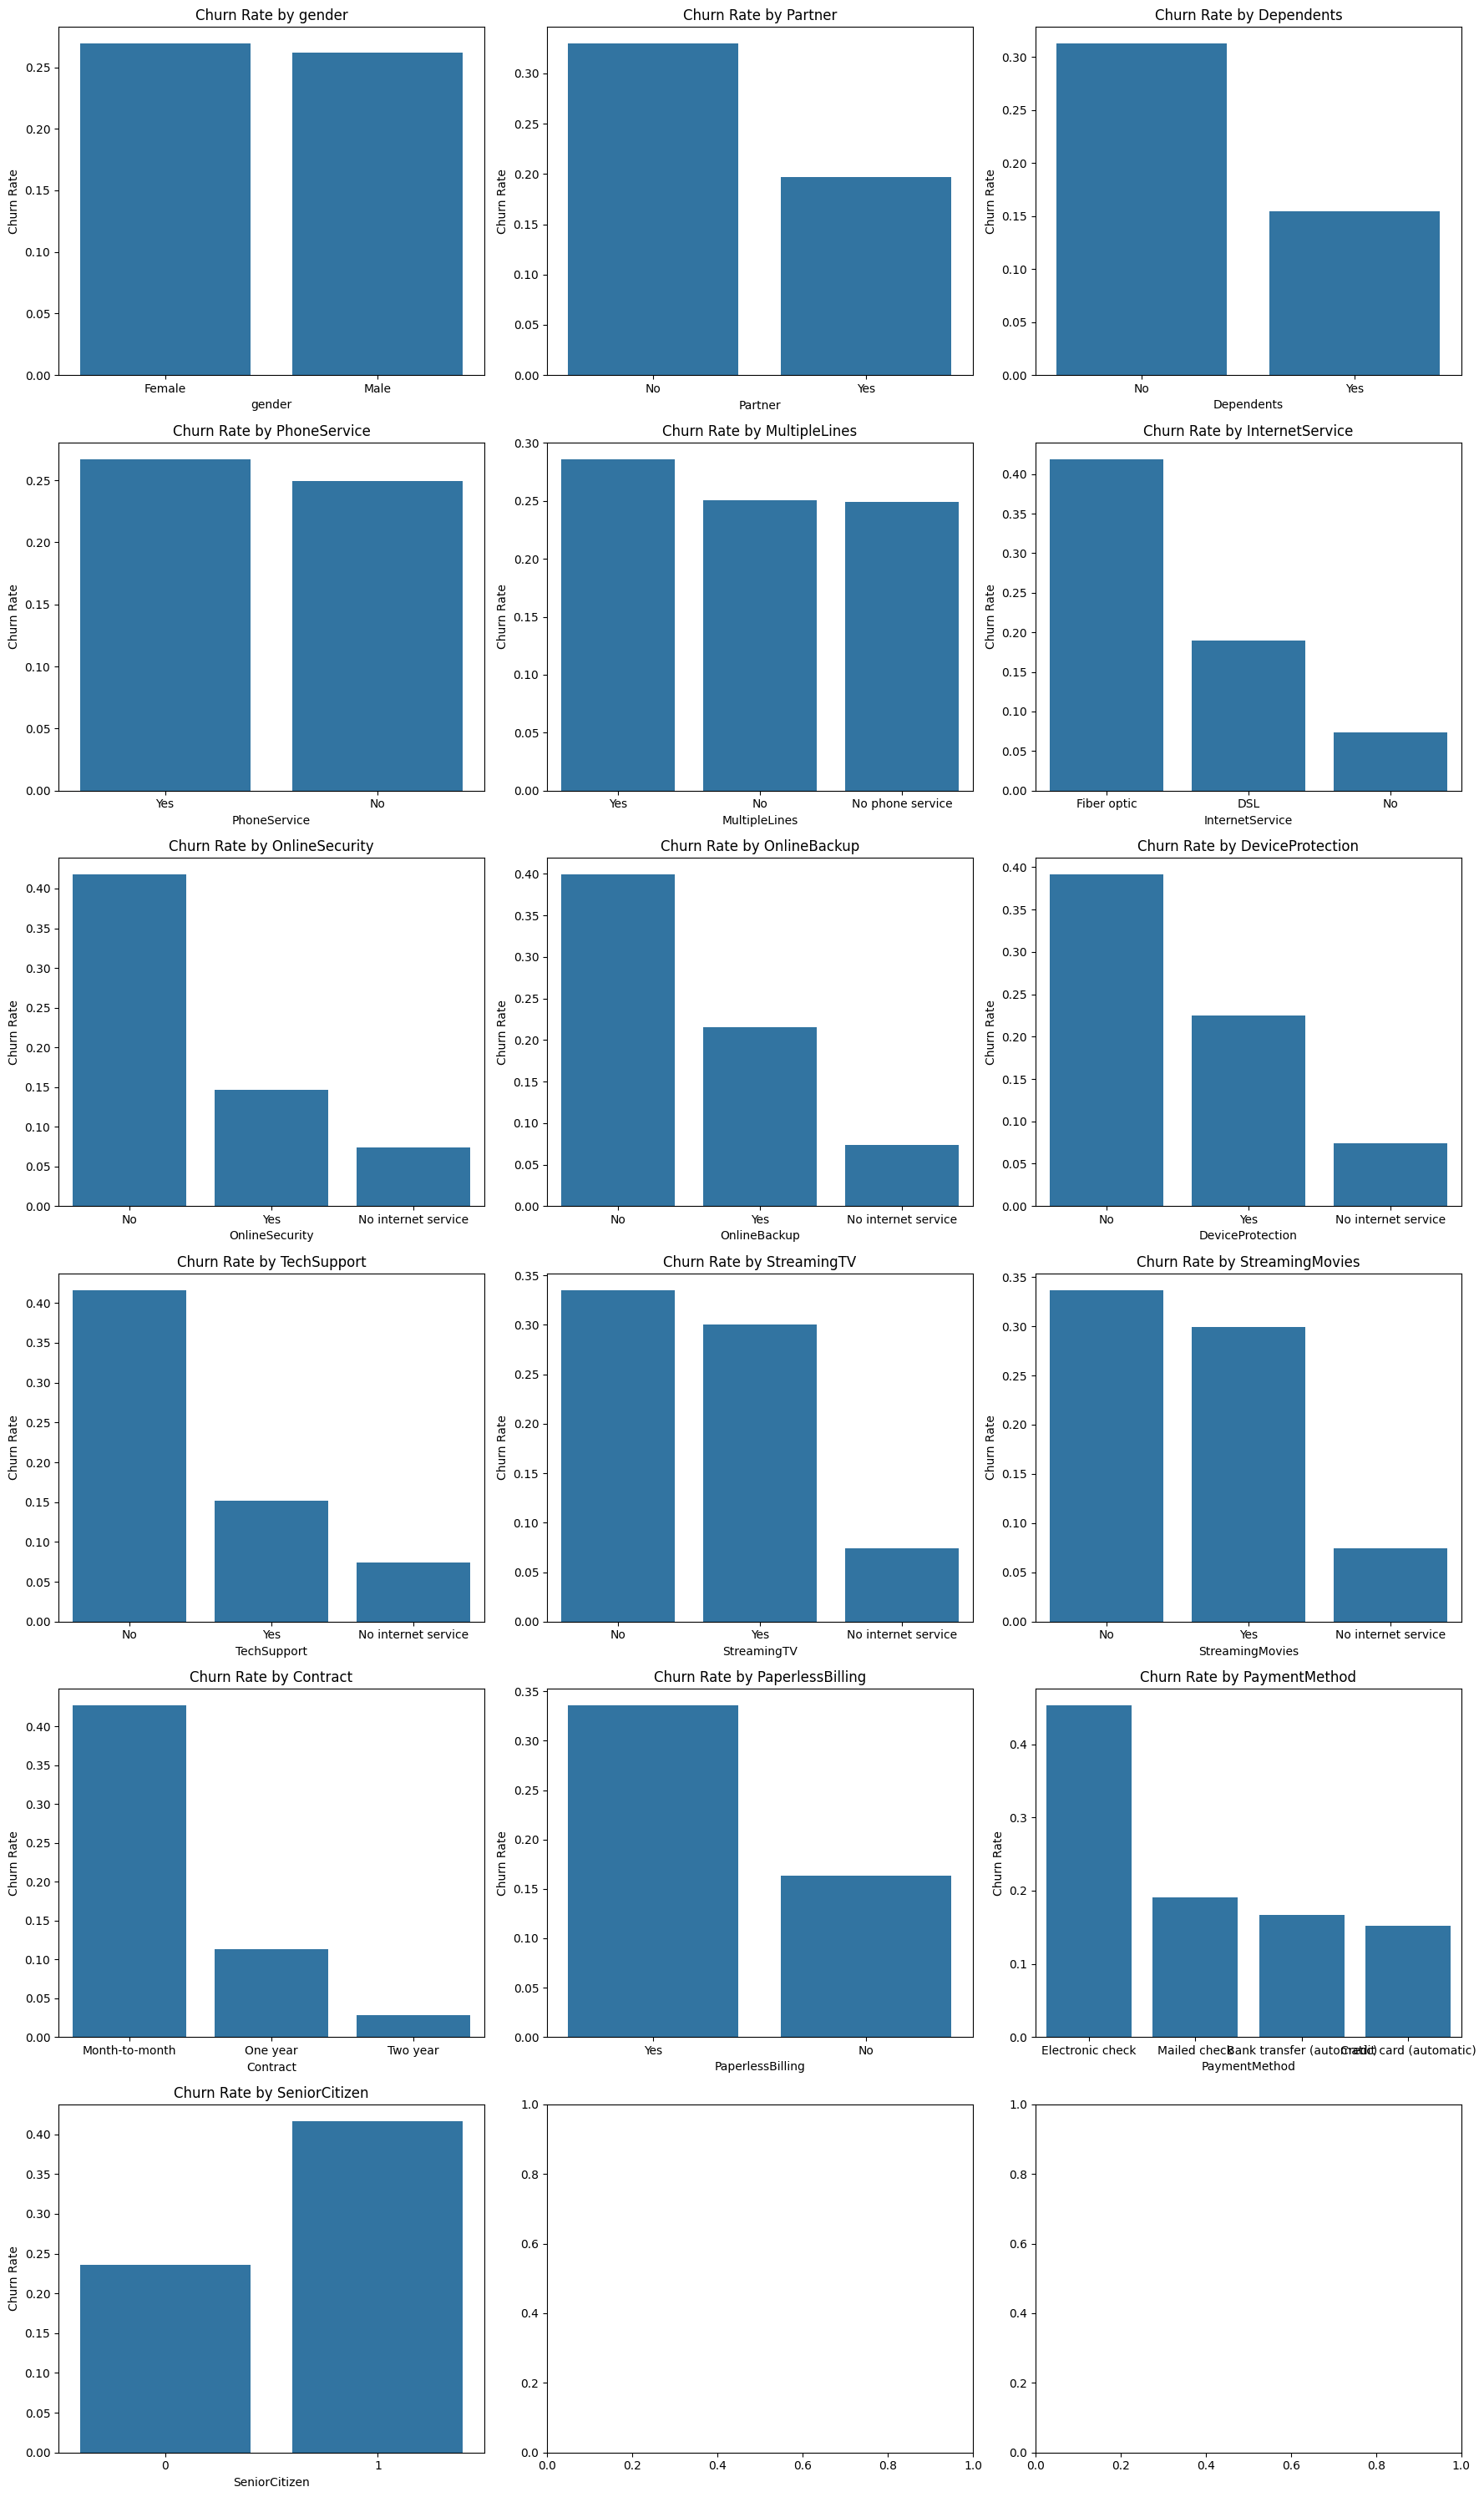

In [45]:
fig, ax = plt.subplots(6, 3, figsize=(18, 30))
ax = ax.flatten()

for i, col in enumerate(categorial_cols):
    churn_rate = pd.crosstab(df[col], df["Churn"], normalize="index")[
        "Yes"
    ].sort_values(ascending=False)

    sns.barplot(x=churn_rate.index, y=churn_rate.values, ax=ax[i])
    ax[i].set_title(f"Churn Rate by {col}")
    ax[i].set_ylabel("Churn Rate")
plt.tight_layout()
plt.show()

### Categorical Features vs Churn – Key Findings

- **Gender and phone service show no significant impact on churn behavior**, as
  churn rates are nearly identical across categories, indicating weak predictive
  power.

- **Customers without partners or dependents exhibit higher churn rates**,
  suggesting that customers with fewer household ties may be more likely to
  discontinue the service.

- **Multiple lines show only a weak association with churn**, with customers
  having multiple lines exhibiting slightly higher churn rates, though the
  difference is marginal.

- **Customers using fiber optic internet service tend to churn more frequently**
  compared to other internet service types, potentially reflecting higher costs
  or elevated service expectations.

- **The absence of value-added services (OnlineSecurity, OnlineBackup,
  DeviceProtection, TechSupport) is strongly associated with higher churn**.
  Customers subscribed to multiple additional services appear more dependent on
  the provider, making them less likely to churn. These features also show
  similar churn patterns, suggesting potential redundancy among them.

- **Streaming services (StreamingTV, StreamingMovies) exhibit a weak relationship
  with churn**, with customers lacking these services showing slightly higher
  churn rates.

- **Contract type shows one of the most pronounced differences in churn rates**, with
  month-to-month customers exhibiting substantially higher churn rates compared
  to customers on long-term contracts.

- **Customers enrolled in paperless billing demonstrate higher churn rates**,
  indicating that digital billing behavior may be associated with increased
  churn risk.

- **Electronic check payment method is strongly associated with higher churn**,
  suggesting that payment friction may play a role in customer retention.

- **Senior citizen customers exhibit higher churn rates**, compared to non-senior customers.
